In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def grow_exponential_tree(network):
    # network = nx.Graph()  # Initialize as a graph
    # counter = 1  # Initialize a counter to create unique node names


    # Get the node and edge list and rename nodes to create a new edge list
    nodes=list(network.nodes())
    edges = list(network.edges())

    highest_node=max(nodes)
    num_nodes=len(nodes)

    renamed_edges = [(highest_node + u, highest_node + v) for u, v in edges]

    # Create new nodes and add them to the network
    new_nodes = range(num_nodes+1, num_nodes+num_nodes+1)
    network.add_nodes_from(new_nodes)

    # make the connection of the old branch to the new branch
    lowest_node = min(new_nodes)
    network.add_edge(1, lowest_node)

    # add the renamed edges to the network
    network.add_edges_from(renamed_edges)

    return(network)

In [3]:
def calculate_max_edge_degree(network):
	# Initialize result variables
	max_edge_degree = -1
	max_edge = None
	for edge in network.edges():
		node1, node2 = edge
		degree_node1 = network.degree(node1)
		degree_node2 = network.degree(node2)
		edge_degree = degree_node1 + degree_node2 - 2
		if (edge_degree > max_edge_degree):
			max_edge_degree = edge_degree
			max_edge = edge
	return([max_edge, max_edge_degree])

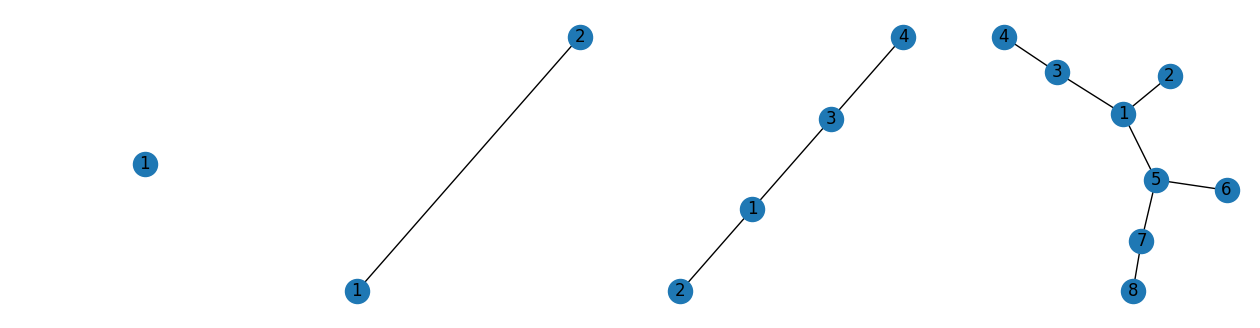

In [4]:
snowflake=nx.Graph()
snowflake.add_node(1)

plt.figure(figsize=(16,4))
plt.subplot(141)

nx.draw(snowflake, with_labels=True)

snowflake=grow_exponential_tree(snowflake)

plt.subplot(142)
nx.draw(snowflake, with_labels=True)

snowflake=grow_exponential_tree(snowflake)

plt.subplot(143)
nx.draw(snowflake, with_labels=True)

snowflake=grow_exponential_tree(snowflake)

plt.subplot(144)
nx.draw(snowflake, with_labels=True)

plt.show()

In [5]:
snowflake=nx.Graph()
snowflake.add_node(1)
snowflake.add_node(2)
snowflake.add_edge(1,2)

num_cells=[len(list(snowflake.nodes()))]
diameter=[nx.diameter(snowflake)]
max_edge_degree=[0]

num_gen=8

for i in range(num_gen):

    snowflake=grow_exponential_tree(snowflake)

    diameter.append(nx.diameter(snowflake))
    num_cells.append(len(list(snowflake.nodes())))
    max_edge_degree.append(calculate_max_edge_degree(snowflake)[1])

num_cells=np.array(num_cells)
diameter=np.array(diameter)

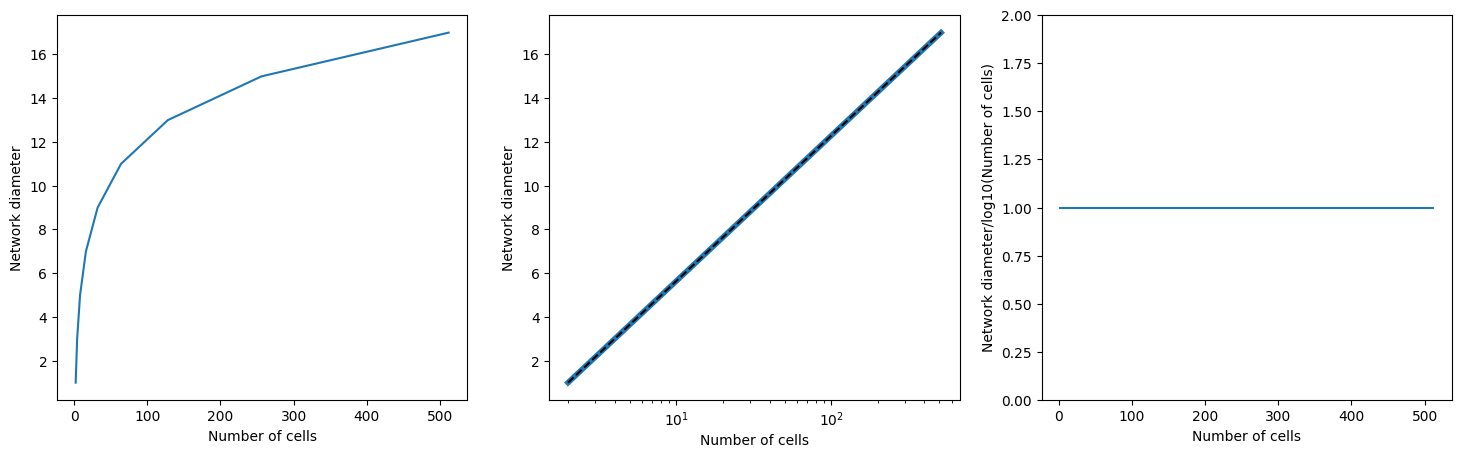

In [6]:
plt.figure(figsize=(18,5))

plt.subplot(131)
plt.plot(num_cells, diameter)
plt.xlabel('Number of cells')
plt.ylabel('Network diameter')

plt.subplot(132)
plt.plot(num_cells, diameter, linewidth=4)
p = np.polyfit(np.log10(num_cells), diameter,1)
plt.plot(num_cells,p[0]*np.log10(num_cells)+p[1],color='black', linestyle='dashed')
plt.xlabel('Number of cells')
plt.ylabel('Network diameter')
plt.xscale('log')


plt.subplot(133)
plt.plot(num_cells, diameter/(p[0]*np.log10(num_cells)+p[1]))
plt.xlabel('Number of cells')
plt.ylabel('Network diameter/log10(Number of cells)')
plt.ylim([0,2])

plt.show()

In [7]:
p

array([ 6.64385619, -1.        ])

In [8]:
diameter/(p[0]*np.log10(num_cells)+p[1])

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

I am trying to find a factor that when dividing the network diameter of an exponential network it will always give me a 1.  
The linear regression formula gives me the equation to predict the network diameter:  
$\text{diameter} = 6.64385619 \times log_{10}(\text{number of nodes}) - 1$  
So the normalization factor that I need to make the network diameter of an exponentially growing network to be 1, is to just divide it by the linear regression, therefore:  
$\text{Normalized network diameter} = \frac{\text{diameter}}{6.64385619 \times log_{10}(\text{number of nodes}) - 1}$ 

In [9]:
max_edge_degree

[0, 2, 4, 6, 8, 10, 12, 14, 16]

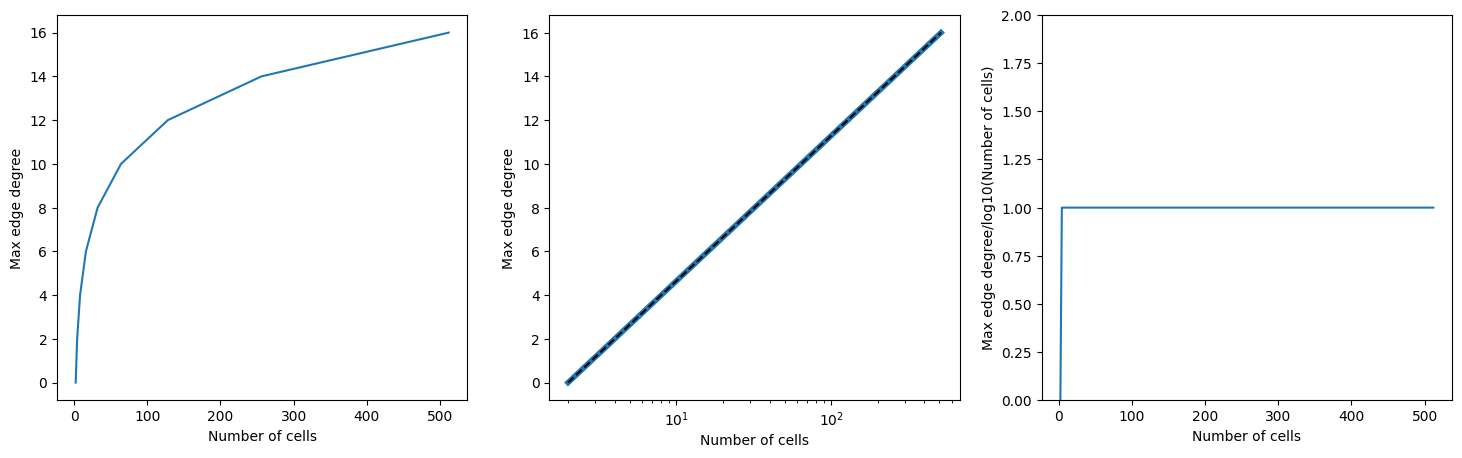

In [10]:
plt.figure(figsize=(18,5))

plt.subplot(131)
plt.plot(num_cells, max_edge_degree)
plt.xlabel('Number of cells')
plt.ylabel('Max edge degree')

plt.subplot(132)
plt.plot(num_cells, max_edge_degree, linewidth=4)
p = np.polyfit(np.log10(num_cells), max_edge_degree,1)
plt.plot(num_cells,p[0]*np.log10(num_cells)+p[1],color='black', linestyle='dashed')
plt.xlabel('Number of cells')
plt.ylabel('Max edge degree')
plt.xscale('log', base=10)


plt.subplot(133)
plt.plot(num_cells, max_edge_degree/(p[0]*np.log10(num_cells)+p[1]))
plt.xlabel('Number of cells')
plt.ylabel('Max edge degree/log10(Number of cells)')
plt.ylim([0,2])

plt.show()